In [ ]:
!pip install transformers torchaudio "onnxruntime==1.20.1" "onnx==1.20.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.8 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login

hf_token = "your_hugging_face_token_here"  # Replace with your actual Hugging Face token

login(token=hf_token)
print("Successfully logged into Hugging Face Hub!")

Successfully logged into Hugging Face Hub!


**Loading the model**

In [ ]:
from transformers import AutoModel
import torch
import torchaudio

# 1. Load the model
print("Loading the model... (This will take a few minutes on first run)")
model = AutoModel.from_pretrained("ai4bharat/indic-conformer-600m-multilingual", trust_remote_code=True)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Model loaded on {device}")



Loading the model... (This will take a few minutes on first run)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py:   0%|          | 0.00/9.64k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual:
- model_onnx.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Please check FRAME_DURATION_MS. The timestamps can be inaccurate


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:115: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Model loaded on cuda


**Importing dataset from huggingface**

In [ ]:
!pip install -q datasets huggingface_hub

from datasets import load_dataset

tamil_valid = load_dataset(
    "ai4bharat/IndicVoices",
    "tamil",
    split="valid",        # the split name inside the config; usually “train” for the data split
    streaming=True       # streams rows on‑demand
)


README.md:   0%|          | 0.00/38.8k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/88 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/78 [00:00<?, ?it/s]

**No. of rows**

In [ ]:
row_count = 0
for _ in tamil_valid:
    row_count += 1
print(f"Number of rows in tamil_valid: {row_count}")

Number of rows in tamil_valid: 5276


**Splitting the dataset**

In [ ]:


num_rows_per_set = row_count // 4

set1 = tamil_valid.take(num_rows_per_set)
set2 = tamil_valid.skip(num_rows_per_set).take(num_rows_per_set)
set3 = tamil_valid.skip(2 * num_rows_per_set).take(num_rows_per_set)
set4 = tamil_valid.skip(3 * num_rows_per_set).take(num_rows_per_set)


print(f"Successfully created set1, set2, set3, set4 each containing {num_rows_per_set} samples.")

Successfully created set1, set2, set3, set4 each containing 1319 samples.


In [ ]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.0 MB/s eta 0:00:00


**One sample of set 1**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio

set1_fresh = tamil_valid.take(num_rows_per_set) # This will create a fresh iterable

# Get the first sample from the fresh set1
first_sample = next(iter(set1_fresh))

# Extract the audio data (waveform array and sampling rate) from the 'audio_filepath' feature
audio_data_decoded = first_sample['audio_filepath'] # This will be {'array': numpy_array, 'sampling_rate': int}
waveform = audio_data_decoded['array']
sampling_rate = audio_data_decoded['sampling_rate']

print(f"Sampling Rate: {sampling_rate} Hz")
print(f"Waveform shape: {waveform.shape}")
print(f"First 10 samples of waveform: {waveform[:10]}")


Sampling Rate: 16000 Hz
Waveform shape: (370080,)
First 10 samples of waveform: [0.01452637 0.01507568 0.01483154 0.01589966 0.01626587 0.01745605
 0.01837158 0.01901245 0.01931763 0.01919556]


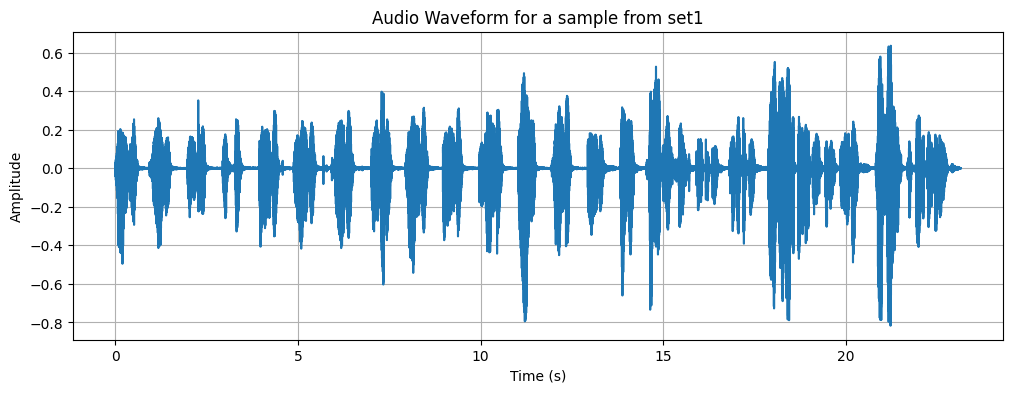

In [ ]:
# Plot the waveform
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(waveform)) / sampling_rate, waveform)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform for a sample from set1")
plt.grid(True)
plt.show()

In [ ]:
# Play the audio
print("\nPlaying audio:")
Audio(waveform, rate=sampling_rate)


Playing audio:


**Preprocess Audio**

In [ ]:
def load_audio2(audio_source, target_sr=16000):
    if isinstance(audio_source, tuple) and len(audio_source) == 2:
        # If input is (array, sr) from the dataset
        waveform_np, original_sr = audio_source
        # Convert numpy array to tensor, add channel dimension (batch_size, channels, samples)
        # Assuming mono audio in the numpy array, add a channel dimension
        waveform = torch.from_numpy(waveform_np).float().unsqueeze(0)
    else:
        # If input is a file path or other supported torchaudio.load type
        waveform, original_sr = torchaudio.load(audio_source)

    # Convert to mono by averaging channels (if not already mono)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample if necessary
    if original_sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=target_sr)
        waveform = resampler(waveform)
    return waveform

# Working on Set1

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set1...")
# Re-initialize set1 to ensure it's not consumed and contains the correct samples
current_set1_iterable = tamil_valid.take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set1_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="ta"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set1 complete. Calculating metrics...")

Starting inference and metric collection for set1...


0it [00:05, ?it/s]


KeyboardInterrupt: 

Calculating WER

In [ ]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 13681
Total substitutions: 3739
Total deletions: 429
Total insertions: 369

--- RNNT Model Results ---
Total reference words: 13681
Total substitutions: 3287
Total deletions: 361
Total insertions: 397


Calculating CER

In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 105846
Total character substitutions: 2896
Total character deletions: 4604
Total character insertions: 2741
CER_ctc: 0.0968

--- RNNT Model Character-level Results ---
Total reference characters: 105846
Total character substitutions: 2978
Total character deletions: 3625
Total character insertions: 2642
CER_rnnt: 0.0873


# Working on Set 2

Running Inference

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set1...")
# Re-initialize set2 to ensure it's not consumed and contains the correct samples
current_set2_iterable = tamil_valid.skip(num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set2_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="ta"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set2 complete. Calculating metrics...")

Starting inference and metric collection for set1...


1319it [55:26,  2.52s/it]

Inference for set2 complete. Calculating metrics...


In [ ]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 14824
Total substitutions: 4371
Total deletions: 555
Total insertions: 410

--- RNNT Model Results ---
Total reference words: 14824
Total substitutions: 3846
Total deletions: 459
Total insertions: 436


In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 115775
Total character substitutions: 3622
Total character deletions: 5661
Total character insertions: 3347
CER_ctc: 0.1091

--- RNNT Model Character-level Results ---
Total reference characters: 115775
Total character substitutions: 3783
Total character deletions: 4423
Total character insertions: 3234
CER_rnnt: 0.0988


# Working on Set 3

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set3...")
# Re-initialize set3 to ensure it's not consumed and contains the correct samples
current_set3_iterable = tamil_valid.skip(2*num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set3_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="ta"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set3 complete. Calculating metrics...")

Starting inference and metric collection for set3...


1319it [1:15:33,  3.44s/it]

Inference for set3 complete. Calculating metrics...


In [ ]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 19257
Total substitutions: 5339
Total deletions: 571
Total insertions: 458

--- RNNT Model Results ---
Total reference words: 19257
Total substitutions: 4704
Total deletions: 510
Total insertions: 454


In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 153611
Total character substitutions: 3852
Total character deletions: 5763
Total character insertions: 4270
CER_ctc: 0.0904

--- RNNT Model Character-level Results ---
Total reference characters: 153611
Total character substitutions: 4030
Total character deletions: 4542
Total character insertions: 3840
CER_rnnt: 0.0808


# Working on Set 4

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set4...")
# Re-initialize set4 to ensure it's not consumed and contains the correct samples
current_set4_iterable = tamil_valid.skip(3*num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set4_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="ta"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set4 complete. Calculating metrics...")

Starting inference and metric collection for set4...


1319it [1:05:37,  2.98s/it]

Inference for set4 complete. Calculating metrics...


In [ ]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 17506
Total substitutions: 5235
Total deletions: 679
Total insertions: 378

--- RNNT Model Results ---
Total reference words: 17506
Total substitutions: 4574
Total deletions: 630
Total insertions: 430


In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 139318
Total character substitutions: 4609
Total character deletions: 6979
Total character insertions: 3826
CER_ctc: 0.1106

--- RNNT Model Character-level Results ---
Total reference characters: 139318
Total character substitutions: 4880
Total character deletions: 5607
Total character insertions: 3583
CER_rnnt: 0.1010
